In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import rasterio

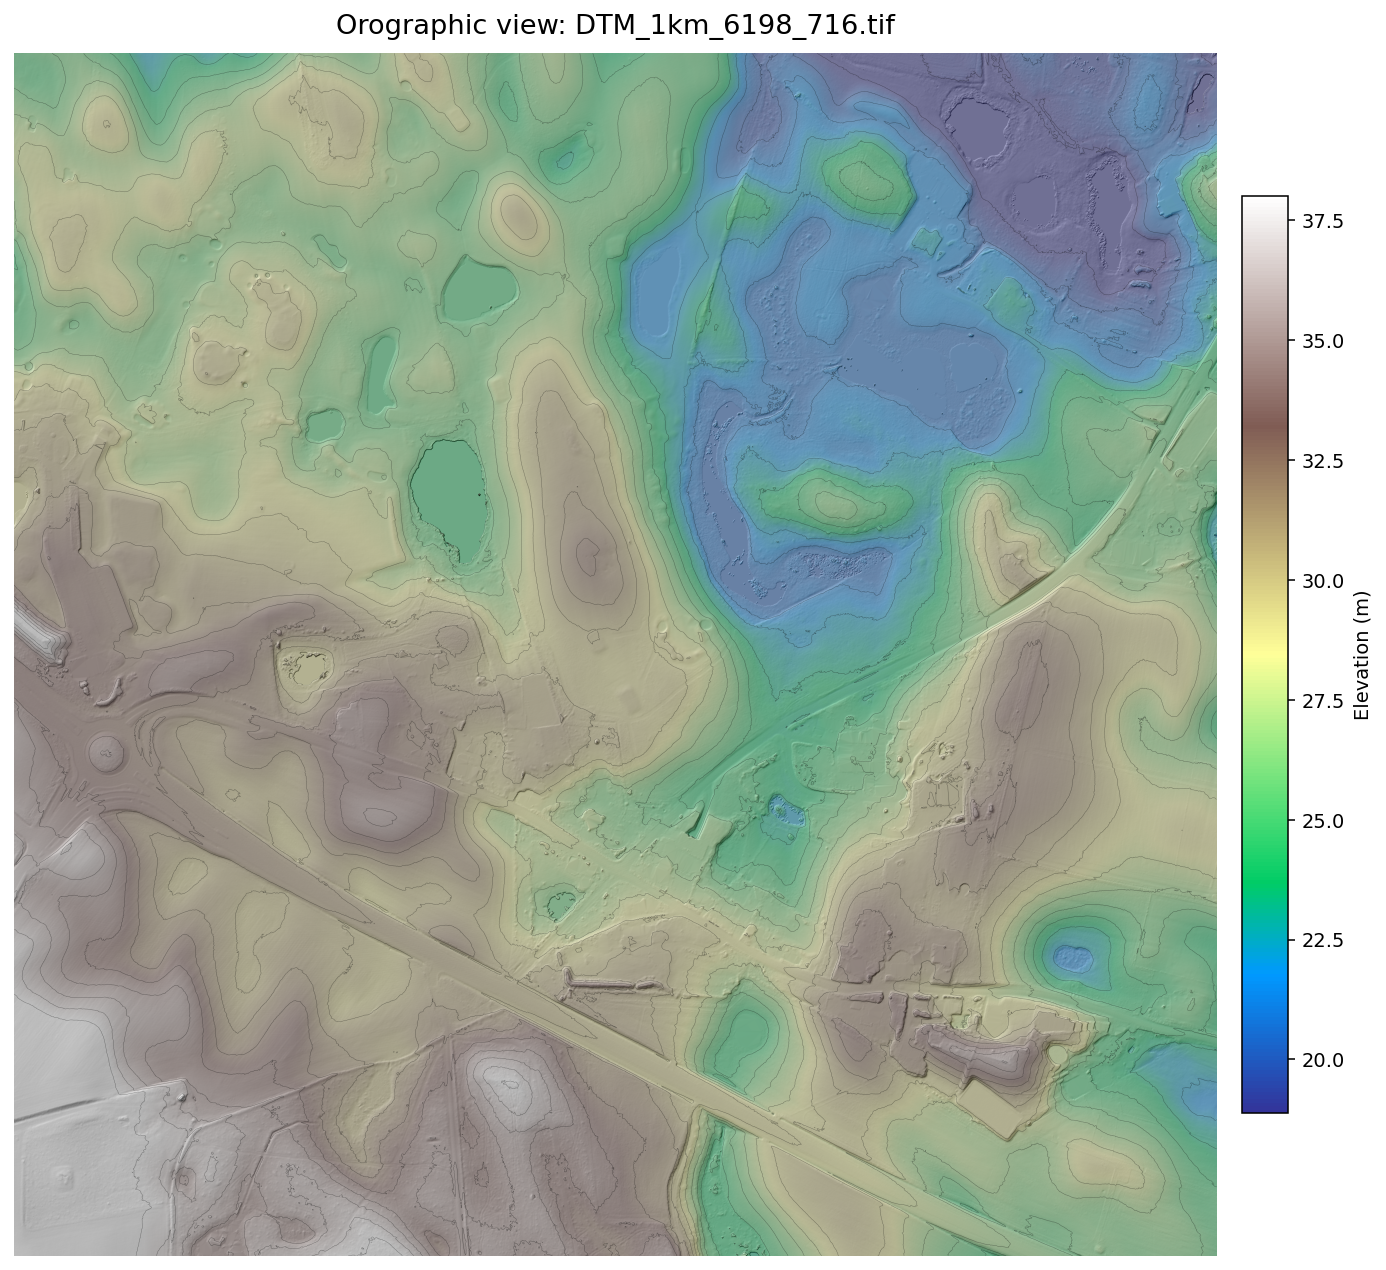

Rendered tile: c:\Users\jacob\OneDrive - Danmarks Tekniske Universitet\UNI\6 semester\Bachelor\Bachelor_legeplads\Hørsholm_tiff\DTM_1km_6198_716.tif


In [19]:
def hillshade(elevation, azimuth=315, altitude=45, z_factor=1.0):
    """Create hillshade from elevation using a simple analytical illumination model."""
    elev = np.asarray(elevation, dtype=float) * z_factor

    dy, dx = np.gradient(elev)
    slope = np.pi / 2.0 - np.arctan(np.hypot(dx, dy))
    aspect = np.arctan2(-dx, dy)

    az = np.deg2rad(azimuth)
    alt = np.deg2rad(altitude)

    shaded = (
        np.sin(alt) * np.sin(slope)
        + np.cos(alt) * np.cos(slope) * np.cos(az - aspect)
    )
    return np.clip(shaded, 0, 1)


# Pick one candidate tile as a first look.
workspace = Path.cwd()
tif_path = workspace / "Hørsholm_tiff" / "DTM_1km_6198_716.tif"

if not tif_path.exists():
    candidates = sorted((workspace / "Hørsholm_tiff").glob("*.tif"))
    if not candidates:
        raise FileNotFoundError("No .tif files found in Hørsholm_tiff")
    tif_path = candidates[0]

with rasterio.open(tif_path) as src:
    dtm = src.read(1, masked=True)
    transform = src.transform

# Fill masked areas for gradient operation.
if np.ma.is_masked(dtm):
    valid_mean = float(dtm.mean())
    dtm_filled = dtm.filled(valid_mean)
else:
    dtm_filled = np.asarray(dtm, dtype=float)

hs = hillshade(dtm_filled, azimuth=320, altitude=35, z_factor=1.6)

# Hypsometric tint + hillshade blend for a more informative relief map.
elev_min, elev_max = np.nanpercentile(dtm_filled, [2, 98])
elev_norm = np.clip((dtm_filled - elev_min) / (elev_max - elev_min + 1e-9), 0, 1)

cmap = plt.get_cmap("terrain")
color_relief = cmap(elev_norm)[..., :3]
shaded_relief = 0.35 * color_relief + 0.65 * hs[..., None]

fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=140)
ax.imshow(shaded_relief, origin="upper")

# Add subtle contour lines.
contour_levels = np.linspace(elev_min, elev_max, 18)
ax.contour(
    dtm_filled,
    levels=contour_levels,
    colors="black",
    linewidths=0.25,
    alpha=0.35,
)

ax.set_title(f"Orographic view: {tif_path.name}", fontsize=14, pad=10)
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

# Add a compact elevation colorbar.
mappable = plt.cm.ScalarMappable(cmap=cmap)
mappable.set_array(dtm_filled)
mappable.set_clim(elev_min, elev_max)
cbar = plt.colorbar(mappable, ax=ax, fraction=0.036, pad=0.02)
cbar.set_label("Elevation (m)")

plt.tight_layout()
plt.show()

print(f"Rendered tile: {tif_path}")

In [ ]:
import plotly.graph_objects as go
from scipy.ndimage import zoom

# Downsample DTM for faster rendering (keep detail but reduce points)
# Use zoom factor to reduce resolution while maintaining shape
zoom_factor = 0.5
dtm_downsampled = zoom(dtm_filled, zoom_factor, order=1)

# Normalize elevation for better color mapping
elev_min_viz = dtm_downsampled.min()
elev_max_viz = dtm_downsampled.max()

# Create 3D surface plot with terrain colormap
fig_3d = go.Figure(
    data=[
        go.Surface(
            z=dtm_downsampled,
            colorscale="Viridis",
            showscale=True,
            colorbar=dict(title="Elevation (m)"),
            name="Terrain",
        )
    ]
)

fig_3d.update_layout(
    title=f"3D Orographic View: {tif_path.name}",
    scene=dict(
        xaxis_title="X (pixels)",
        yaxis_title="Y (pixels)",
        zaxis_title="Elevation (m)",
        aspectratio=dict(x=1, y=1, z=0.6),
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.3)
        ),
    ),
    width=1000,
    height=800,
    hovermode="closest",
)

fig_3d.show()
print(f"3D interactive view created for: {tif_path.name}")

ImportError: cannot import name 'zoom' from 'scipy.interpolate' (c:\Users\jacob\anaconda3\envs\BachelorProjekt26\Lib\site-packages\scipy\interpolate\__init__.py)